                                SIMULATION ADVANCED REPORT
                                 Total Run Time: 100 min
Machine ID   | Uptime (m)  | Downtime (m)  | Breakdowns  | Avg Repair  | Avg Wait  | Util (%)
-----------------------------------------------------------------------------------------------
Machine 1    | 100.0       | 0.0           | 0           | 0.0         | 0.0       | 100.0   
Machine 2    | 96.1        | 3.9           | 1           | 3.9         | 0.0       | 96.1    
Machine 3    | 100.0       | 0.0           | 0           | 0.0         | 0.0       | 100.0   
Machine 4    | 88.2        | 11.8          | 1           | 11.8        | 0.0       | 88.2    
Machine 5    | 100.0       | 0.0           | 0           | 0.0         | 0.0       | 100.0   
-----------------------------------------------------------------------------------------------
Total System Throughput: 2178 parts
System Configurations  : MTBF=100.0m | Weibull Scale=15.0 (Shape=2.0) | Repairman=1


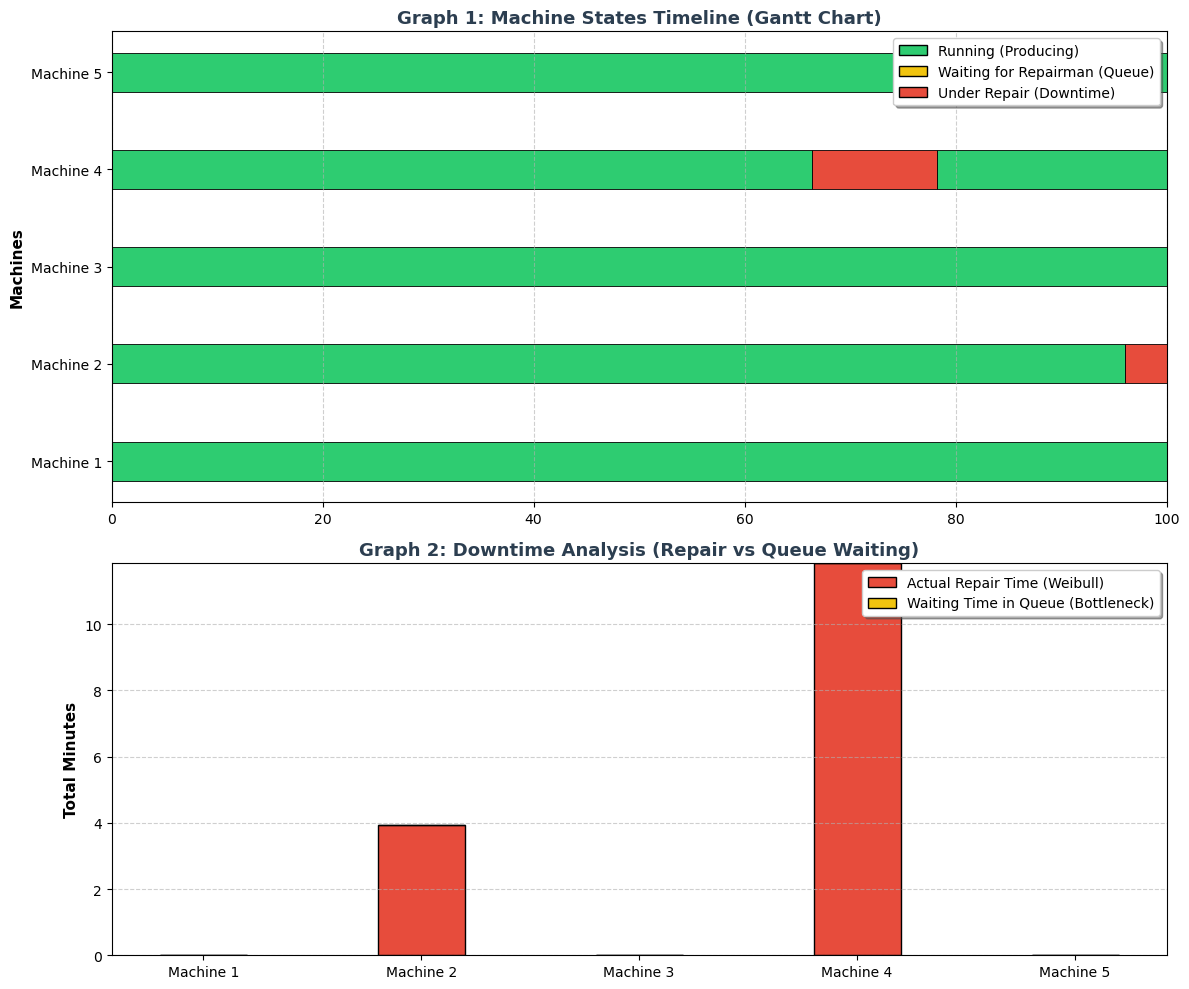

In [4]:
import random
import matplotlib.pyplot as plt
import numpy as np
import simpy
from matplotlib.patches import Patch


NUM_MACHINES = 5
SIM_TIME = 100  

MTBF = 100.0  
WEIBULL_SHAPE = 2.0
WEIBULL_SCALE = 15.0
PRODUCTION_RATE = 4.5  


machine_downtime = np.zeros(NUM_MACHINES)
machine_waitingtime = np.zeros(NUM_MACHINES)
machine_uptime = np.zeros(NUM_MACHINES)
machine_breakdowns = np.zeros(NUM_MACHINES)  
total_parts_produced = 0

gantt_data = {i: [] for i in range(NUM_MACHINES)}



def machine_process(env, machine_id, repairman):
    global total_parts_produced

    while True:
        # ক. সচল অবস্থা (Running State)
        tbb = random.expovariate(1.0 / MTBF)
        if env.now + tbb > SIM_TIME:
            actual_run_time = SIM_TIME - env.now
            machine_uptime[machine_id] += actual_run_time
            gantt_data[machine_id].append((env.now, actual_run_time, "#2ecc71"))  
            total_parts_produced += actual_run_time * PRODUCTION_RATE
            yield env.timeout(actual_run_time)
            break

        machine_uptime[machine_id] += tbb
        gantt_data[machine_id].append((env.now, tbb, "#2ecc71"))
        total_parts_produced += tbb * PRODUCTION_RATE
        yield env.timeout(tbb)

        
        breakdown_time = env.now
        machine_breakdowns[machine_id] += 1  

        with repairman.request() as req:
            yield req  

            waiting_time = env.now - breakdown_time
            if waiting_time > 0:
                machine_waitingtime[machine_id] += waiting_time
                gantt_data[machine_id].append((breakdown_time, waiting_time, "#f1c40f"))  # হলুদ

            # গ. মেরামত অবস্থা (Repair State)
            repair_time = random.weibullvariate(WEIBULL_SCALE, WEIBULL_SHAPE)
            if env.now + repair_time > SIM_TIME:
                repair_time = SIM_TIME - env.now

            machine_downtime[machine_id] += repair_time
            gantt_data[machine_id].append((env.now, repair_time, "#e74c3c"))  # লাল
            yield env.timeout(repair_time)



env = simpy.Environment()
repairman = simpy.Resource(env, capacity=1)  # ১ জন মেকানিক

for i in range(NUM_MACHINES):
    env.process(machine_process(env, i, repairman))

env.run(until=SIM_TIME)


print("=" * 95)
print(f"                                SIMULATION ADVANCED REPORT")
print(f"                                 Total Run Time: {SIM_TIME} min")
print("=" * 95)
# টেবিল হেডার
print(
    f"{'Machine ID':<12} | {'Uptime (m)':<11} | {'Downtime (m)':<13} | {'Breakdowns':<11} | {'Avg Repair':<11} | {'Avg Wait':<9} | {'Util (%)':<8}"
)
print("-" * 95)

# টেবিল রো বা বডি প্রিন্ট করা
for i in range(NUM_MACHINES):
    utilization = (machine_uptime[i] / SIM_TIME) * 100
    num_fails = machine_breakdowns[i]


    avg_rep = machine_downtime[i] / num_fails if num_fails > 0 else 0.0
    avg_wait = machine_waitingtime[i] / num_fails if num_fails > 0 else 0.0

    print(
        f"Machine {i+1:<4} | {machine_uptime[i]:<11.1f} | {machine_downtime[i]:<13.1f} | {int(num_fails):<11} | {avg_rep:<11.1f} | {avg_wait:<9.1f} | {utilization:<8.1f}"
    )

print("-" * 95)
print(f"Total System Throughput: {int(total_parts_produced)} parts")
print(
    f"System Configurations  : MTBF={MTBF}m | Weibull Scale={WEIBULL_SCALE} (Shape={WEIBULL_SHAPE}) | Repairman=1"
)
print("=" * 95)


fig, (ax_gantt, ax_breakdown) = plt.subplots(2, 1, figsize=(12, 10), gridspec_kw={"height_ratios": [1.2, 1]})


for machine_id, events in gantt_data.items():
    for start, duration, color in events:
        ax_gantt.barh(
            y=f"Machine {machine_id+1}",
            width=duration,
            left=start,
            color=color,
            edgecolor="black",
            linewidth=0.6,
            height=0.4,
        )

legend_elements = [
    Patch(facecolor="#2ecc71", edgecolor="black", label="Running (Producing)"),
    Patch(facecolor="#f1c40f", edgecolor="black", label="Waiting for Repairman (Queue)"),
    Patch(facecolor="#e74c3c", edgecolor="black", label="Under Repair (Downtime)"),
]
ax_gantt.legend(handles=legend_elements, loc="upper right", frameon=True, shadow=True)
ax_gantt.set_ylabel("Machines", fontsize=11, fontweight="bold")
ax_gantt.set_title("Graph 1: Machine States Timeline (Gantt Chart)", fontsize=13, fontweight="bold", color="#2c3e50")
ax_gantt.set_xlim(0, SIM_TIME)
ax_gantt.grid(axis="x", linestyle="--", alpha=0.6)


machines = [f"Machine {i+1}" for i in range(NUM_MACHINES)]
ax_breakdown.bar(machines, machine_downtime, label="Actual Repair Time (Weibull)", color="#e74c3c", edgecolor="black", width=0.4)
ax_breakdown.bar(
    machines,
    machine_waitingtime,
    bottom=machine_downtime,
    label="Waiting Time in Queue (Bottleneck)",
    color="#f1c40f",
    edgecolor="black",
    width=0.4,
)
ax_breakdown.set_ylabel("Total Minutes", fontsize=11, fontweight="bold")
ax_breakdown.set_title(
    "Graph 2: Downtime Analysis (Repair vs Queue Waiting)", fontsize=13, fontweight="bold", color="#2c3e50"
)
ax_breakdown.legend(loc="upper right", frameon=True, shadow=True)
ax_breakdown.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()